# **Global Data Science Job Salary Analysis**
**____________________________________________________________________**

# **Import Libraries**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import plotly.express as px

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", None)

# **Read the Raw Data CSV File**

In [ ]:
jobs = pd.read_csv('https://raw.githubusercontent.com/jecka0627/ds_global_job_salaries/refs/heads/main/ds_job_salaries_analysis/ds_job_salaries.csv')

#**Dataset Overview**
In this section, I performed the initial inspection of the dataset, such as how many rows and columns, the number of unique value, and a preview of the data (the first 10 rows).

In [16]:
print("Dataset Shape:", jobs.shape) #Dataset shape
print("Unique job titles:", jobs["job_title"].nunique()) #job titles available
print("Countries represented:", jobs["company_location"].nunique()) # countries available

print("First Ten Rows: ")
jobs.head(10)

Dataset Shape: (3755, 11)
Unique job titles: 93
Countries represented: 72
First Ten Rows: 


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
5,2023,SE,FT,Applied Scientist,222200,USD,222200,US,0,US,L
6,2023,SE,FT,Applied Scientist,136000,USD,136000,US,0,US,L
7,2023,SE,FT,Data Scientist,219000,USD,219000,CA,0,CA,M
8,2023,SE,FT,Data Scientist,141000,USD,141000,CA,0,CA,M
9,2023,SE,FT,Data Scientist,147100,USD,147100,US,0,US,M


# **Understanding the Data**
This is the section where I explore the dataset by examining its structure, data types, and summary statistics to gain a better understanding of the available information.

In [17]:
#Column Names
jobs.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [18]:
#Data Types
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [61]:
#Descriptive Statistics
jobs.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,2584.000000,2.584000e+03,2584.000000,2584.000000
mean,2022.301084,2.103653e+05,133409.280186,50.483746
std,0.749179,8.080375e+05,67136.837329,48.163707
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,9.000000e+04,84975.000000,0.000000
50%,2022.000000,1.346300e+05,130000.000000,50.000000
75%,2023.000000,1.825625e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


Salary distribution is highly skewed in raw salary values due to extreme outliers. Which is why salary in USD is a more reliable metric for comparison and analysis.

The dataset contains salary information for 3755 data science roles across 72 different countries and 93 job titles



# **DATA CLEANING**

### **CHECKING MISSING VALUES**

In [20]:
jobs.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


### **CHECKING DUPLICATES**

In [21]:
jobs.duplicated().sum()

np.int64(1171)

In [22]:
jobs[jobs.duplicated(keep=False)].sort_values(by=list(jobs.columns))

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
3119,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3120,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3502,2021,MI,FT,Data Engineer,200000,USD,200000,US,100,US,L
3586,2021,MI,FT,Data Engineer,200000,USD,200000,US,100,US,L
3665,2021,MI,FT,Data Scientist,76760,EUR,90734,DE,50,DE,L
...,...,...,...,...,...,...,...,...,...,...,...
525,2023,SE,FT,Research Scientist,250000,USD,250000,US,0,US,M
956,2023,SE,FT,Research Scientist,250000,USD,250000,US,0,US,M
1751,2023,SE,FT,Research Scientist,250000,USD,250000,US,0,US,M
1247,2023,SE,FT,Research Scientist,253750,USD,253750,ES,0,ES,M


No missing values but duplicate rows were detected in the dataset. Since these records contain identical information across all variables, they are likely the result of dataset aggregation or export issues. So, removing duplicates ensures that salary statistics are not artificially inflated.

In [23]:
jobs= jobs.drop_duplicates()
jobs.duplicated().sum()

np.int64(0)

In [24]:
print("Dataset Shape:", jobs.shape) #Dataset shape
print("Unique job titles:", jobs["job_title"].nunique()) #job titles available
print("Countries represented:", jobs["company_location"].nunique()) # countries available
print()
jobs.info()

Dataset Shape: (2584, 11)
Unique job titles: 93
Countries represented: 72

<class 'pandas.core.frame.DataFrame'>
Index: 2584 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           2584 non-null   int64 
 1   experience_level    2584 non-null   object
 2   employment_type     2584 non-null   object
 3   job_title           2584 non-null   object
 4   salary              2584 non-null   int64 
 5   salary_currency     2584 non-null   object
 6   salary_in_usd       2584 non-null   int64 
 7   employee_residence  2584 non-null   object
 8   remote_ratio        2584 non-null   int64 
 9   company_location    2584 non-null   object
 10  company_size        2584 non-null   object
dtypes: int64(4), object(7)
memory usage: 242.2+ KB


After the removal of the duplicates our cleaned dataset contains salary information for 2584 data science roles across 72 different countries and 93 job titles

# **EXPLORATORY DATA ANALYSIS**

This is where I explore patterns across different context such as experience level, company size, and work arrangements

### **Salary Analysis**

In [26]:
#Average Salary
jobs['salary_in_usd'].mean()

np.float64(133409.28018575851)

In [27]:
#Highest Salary
jobs['salary_in_usd'].max()

450000

In [28]:
#Lowest Salary
jobs['salary_in_usd'].min()

5132

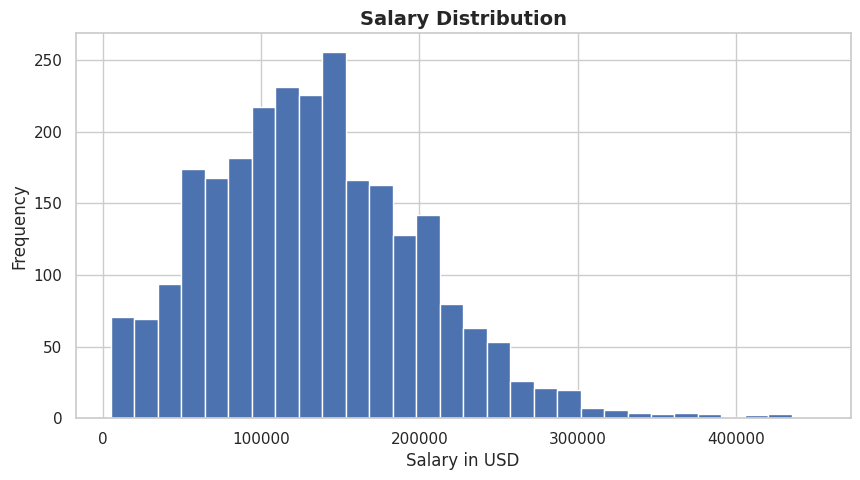

In [29]:
#SALARY DISTRIBUTION
plt.figure(figsize=(10,5))
plt.hist(jobs['salary_in_usd'], bins=30)
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')
plt.title('Salary Distribution')
plt.show()

As the salary distribution is still highly skewed even after using the USD currency, means that the dataset contains extreme values that can distort the mean. So, I'll be using the median salary throughout the analysis as the central tendency, which will reduce the influence of the extreme values.

### **Salary by Experience Level Analysis**

In [68]:
exp_order = ['EN', 'MI', 'SE', 'EX']
exp_labels = {'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'}

jobs['experience_level'].map(exp_labels).value_counts().reindex(['Entry-level', 'Mid-level', 'Senior', 'Executive'])

,count
experience_level,
Entry-level,270
Mid-level,664
Senior,1554
Executive,96


In [66]:
jobs.groupby('experience_level')['salary_in_usd'].median().reindex(exp_order).rename(exp_labels)

,salary_in_usd
experience_level,
Entry-level,61900.0
Mid-level,95000.0
Senior,148800.0
Executive,189618.5


Salary shows a clear upward progression with experience — from a median of 62K USD at Entry-level, up to 190K USD at Executive level. The salary spread also widens at higher levels, indicating greater compensation variability among senior and executive roles.

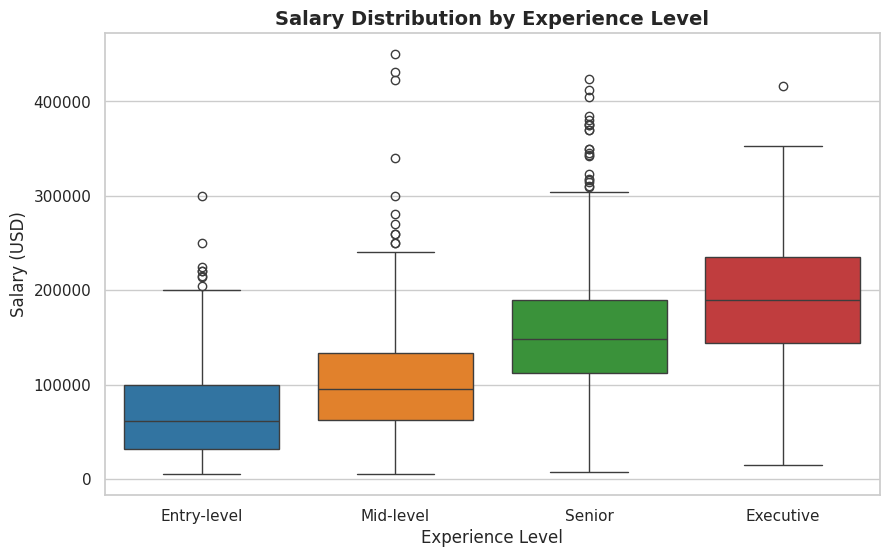

In [69]:
exp_order = ['EN', 'MI', 'SE', 'EX']
exp_labels = {'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'}

jobs['exp_label'] = jobs['experience_level'].map(exp_labels)
order_labels = ['Entry-level', 'Mid-level', 'Senior', 'Executive']

sns.boxplot(
    x='exp_label',
    y='salary_in_usd',
    data=jobs,
    order=order_labels,
    palette='tab10'
)

plt.title('Salary Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.show()

In [33]:
jobs[jobs["salary_in_usd"] > 400000][["job_title","experience_level","company_location"]]

,job_title,experience_level,company_location
528,AI Scientist,SE,IL
2011,Data Analyst,MI,GB
3463,Data Analytics Lead,SE,US
3522,Research Scientist,MI,US
3675,Principal Data Scientist,EX,US
3747,Applied Machine Learning Scientist,MI,US
3750,Data Scientist,SE,US


Salaries above 400K USD were observed across multiple experience levels, including mid-level roles such as Data Analyst and Research Scientist, primarily in high-paying regions like the US and IL. These valid high-compensation cases were retained in the analysis, as they highlight that job role and location can strongly influence salary beyond experience level alone.

### **Salary by Company Size Analysis**

In [34]:
#Company Size
jobs['company_size'].value_counts()

,count
company_size,
M,2028
L,409
S,147


In [35]:
jobs["company_size"].value_counts(normalize=True)

,proportion
company_size,
M,0.784830
L,0.158282
S,0.056889


The dataset shows an uneven but sufficiently large distribution of company sizes, with medium-sized companies dominating the sample (≈78.5%), followed by large companies (≈15.8%), and small companies (≈5.7%). While the dataset is not perfectly balanced, each category contains enough observations to support meaningful comparison of salary patterns across company sizes.

In [36]:
jobs.groupby('company_size')['salary_in_usd'].median()

,salary_in_usd
company_size,
L,100000.0
M,137067.5
S,62726.0


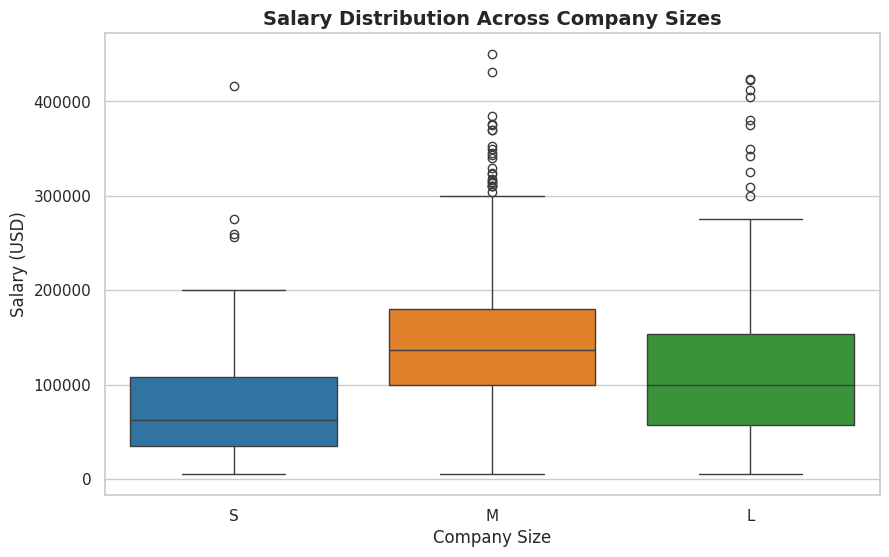

In [70]:
order= ["S", "M", "L"]

sns.boxplot(
    x="company_size",
    y="salary_in_usd",
    data=jobs,
    order=order,
    palette="tab10"
)

plt.title("Salary Distribution Across Company Sizes")
plt.xlabel("Company Size")
plt.ylabel("Salary (USD)")

plt.show()

Salary analysis reveals a clear relationship between company size and compensation levels. Medium-sized companies offer the highest median salary at approximately 137k, followed by large companies at 100k, while small companies report the lowest median salary at around 62.7k. This indicates the mid-sized organizations tend to provide more competitive compensation, potentially due to a balance between resource availability and organizational flexibility. In contrast, small companies appear to offer significantly lower pay, likely reflecting budget constraints, while large companies show moderate compensation levels with wider variability.

Overall, the results suggest that company size is a relevant factor in salary determination, with meduim-sized companies emerging as the most favorable in terms of median compensation within this dataset

### **Salary by Remote Work Analysis**

In [39]:
jobs["remote_ratio"].unique()

array([100,   0,  50])

In [40]:
jobs["remote_ratio"].value_counts()

,count
remote_ratio,
100,1211
0,1186
50,187


In [41]:
#The variable remote_ratio represents the proportion of remote work:
  #0 → On-site
  #50 → Hybrid
  #100 → Remote

jobs["remote_type"]= jobs["remote_ratio"].map({
    0: "On-site",
    50: "Hybrid",
    100: "Remote"
})

jobs['remote_type'].value_counts()

,count
remote_type,
Remote,1211
On-site,1186
Hybrid,187


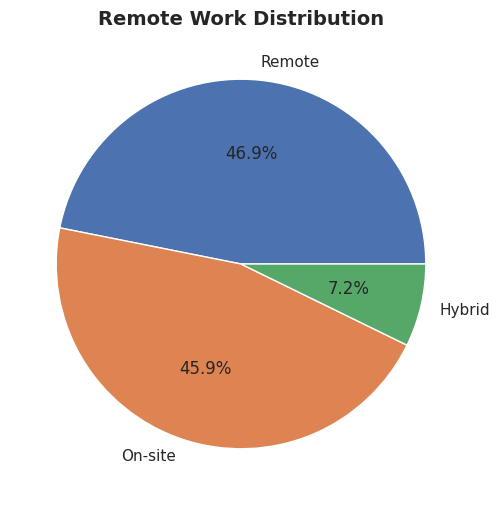

In [42]:
#REMOTE WORK DISTRIBUTION

remote_counts = jobs['remote_type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(remote_counts.values, labels=remote_counts.index, autopct='%1.1f%%')
plt.title('Remote Work Distribution')
plt.show()

Remote (1,211) and On-site (1,186) are nearly equal in count, while Hybrid (187) is significantly underrepresented at only 7.2% of the dataset.

In [79]:
jobs.groupby('remote_type')['salary_in_usd'].median().sort_values(ascending=False)

,salary_in_usd
remote_type,
On-site,137500.0
Remote,130000.0
Hybrid,63312.0


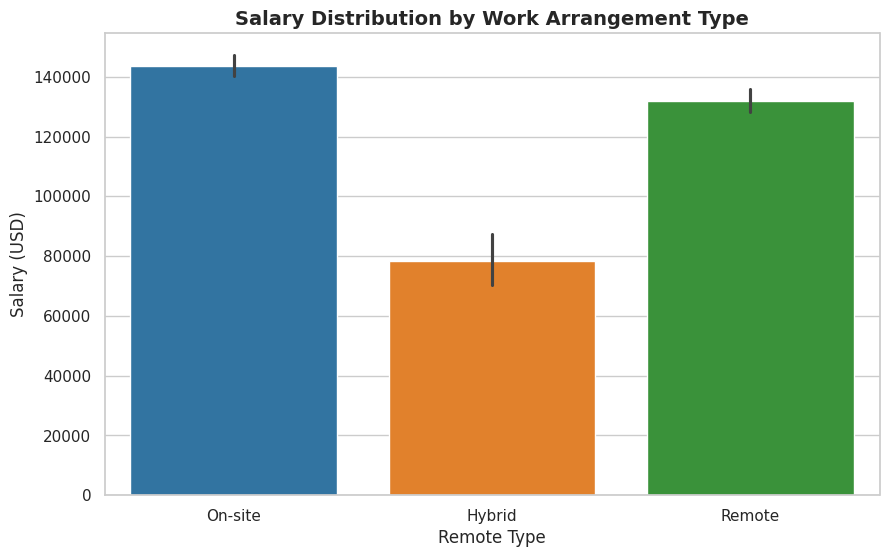

In [71]:
#to check which job type pays more
order= ["On-site", "Hybrid", "Remote"]

sns.barplot(x= "remote_type",
            y= "salary_in_usd",
            data= jobs,
            order=order,
            palette="tab10",
            )

plt.title("Salary Distribution by Work Arrangement Type")
plt.xlabel("Remote Type")
plt.ylabel("Salary (USD)")

plt.show()

The dataset shows that while remote work is the most common arrangement, on-site positions offer the highest median salary at $137,500, slightly above remote roles at 130,000 USD. Hybrid work trails significantly at 63,312 USD, though this may be due to its small sample size of only 187 entries. This suggests that compensation is likely influenced by job structure, seniority, or location-specific roles rather than work arrangement alone, meaning remote work itself is not the sole driver of higher salaries.

### **Salary by Country Analysis**

Company location is likely to have a strong effect on salary levels. In data-related roles, pay tends to vary across countries because of differences in cost of living, labor market conditions, and the demand for skilled professionals.

In [44]:
#Top Countries by Job Count
jobs['company_location'].value_counts().head(10)

,count
company_location,
US,1929
GB,155
CA,83
IN,57
DE,55
ES,44
FR,33
BR,15
AU,14


In [48]:
#Highest Paying Countries
jobs.groupby('company_location')['salary_in_usd'].median().sort_values(ascending=False).head(10)

,salary_in_usd
company_location,
IL,271446.5
PR,167500.0
US,145885.0
NZ,125000.0
BA,120000.0
CA,120000.0
AE,115000.0
RU,106000.0
SE,105000.0


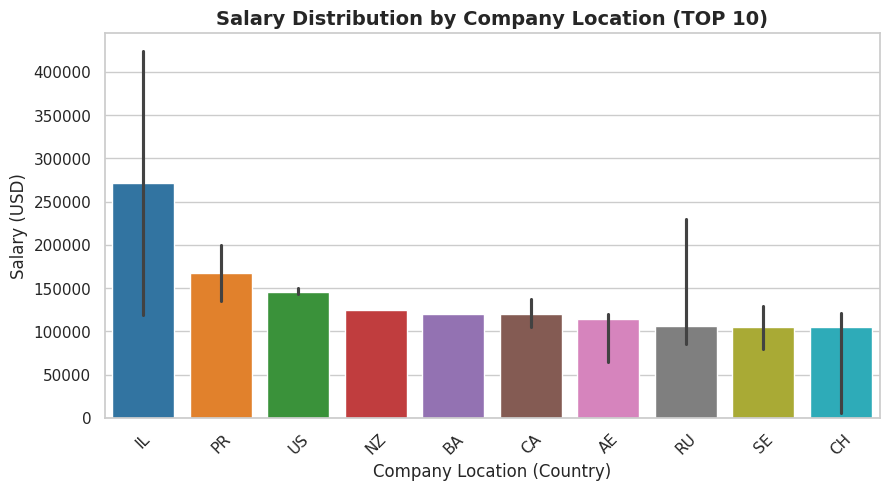

In [46]:
order = jobs.groupby('company_location')['salary_in_usd'].median().sort_values(ascending=False).head(10).index

plt.figure(figsize=(10,5))

sns.barplot(
    x="company_location",
    y="salary_in_usd",
    data=jobs,
    estimator=np.median,
    order=order,
    palette="tab10"
)

plt.title("Salary Distribution by Company Location (TOP 10)")
plt.xlabel("Company Location (Country)")
plt.ylabel("Salary (USD)")
plt.xticks(rotation=45)

plt.show()

While IL and PR show the highest median salaries, its wide variability and small sample sizes make these figures less reliable. High salaries don't always mean high opportunity, the US, despite ranking 3rd in salary, offers the best balance of compensation and job volume, making it the most data-rich and statistically robust benchmark for data science compensation globally.

### **Top Paying Job Titles**

In [55]:
jobs["job_title"].nunique()

93

In [51]:
jobs["job_title"].value_counts()

,count
job_title,
Data Engineer,598
Data Scientist,538
Data Analyst,396
Machine Learning Engineer,206
Analytics Engineer,91
...,...
Principal Data Architect,1
Head of Machine Learning,1
Cloud Data Architect,1


The dataset contains 93 unique job titles. To maintain clarity and statistical reliability, the analysis focuses on the 10 most frequently occurring roles.

In [58]:
top_jobs = jobs["job_title"].value_counts().head(10).index

df_jobs = jobs[jobs["job_title"].isin(top_jobs)]

df_jobs.groupby("job_title")["salary_in_usd"].median().sort_values(ascending=False).head(10)

,salary_in_usd
job_title,
Data Science Manager,175100.0
Data Architect,163750.0
ML Engineer,160000.0
Research Engineer,155000.0
Research Scientist,145900.0
Machine Learning Engineer,145000.0
Analytics Engineer,143860.0
Data Engineer,135000.0
Data Scientist,132600.0


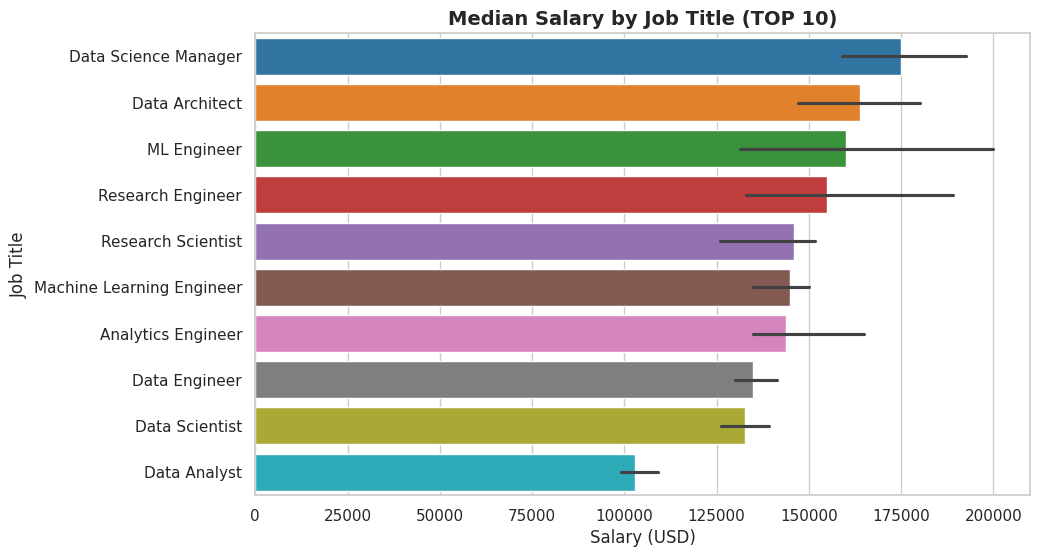

In [62]:
top_jobs = jobs["job_title"].value_counts().head(10).index

df_jobs = jobs[jobs["job_title"].isin(top_jobs)]

order = df_jobs.groupby("job_title")["salary_in_usd"].median().sort_values(ascending=False).index

sns.barplot(
    x="salary_in_usd",
    y="job_title",
    data=df_jobs,
    estimator=np.median,
    order=order,
    palette="tab10"
)

plt.title("Median Salary by Job Title (TOP 10)")
plt.xlabel("Salary (USD)")
plt.ylabel("Job Title")

plt.show()

Among the most frequently occurring roles in the dataset, managerial and specialized engineering positions command the highest salaries, while Data Analyst remains the entry-level benchmark at ~$103K. Notably, the ML Engineer role shows the widest salary variability, as seen by its long error bar, indicating high earning potential but inconsistent pay across companies.

## **Salary Trend Over Time**

In [72]:
jobs.groupby('work_year')['salary_in_usd'].median()

,salary_in_usd
work_year,
2020,74130.0
2021,80000.0
2022,129300.0
2023,140000.0


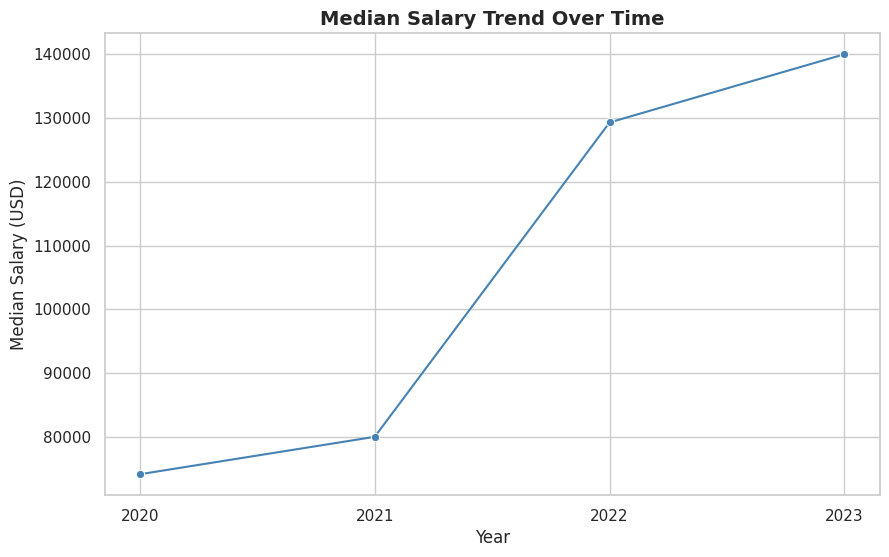

In [73]:
yearly_salary = jobs.groupby('work_year')['salary_in_usd'].median().reset_index()

sns.lineplot(
    x='work_year',
    y='salary_in_usd',
    data=yearly_salary,
    marker='o',
    color='steelblue'
)

plt.title('Median Salary Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Median Salary (USD)')
plt.xticks([2020, 2021, 2022, 2023])
plt.show()

Data science salaries nearly doubled between 2020 and 2023, with the most dramatic increase occurring between 2021 and 2022. This sharp mid-period jump likely reflects the post-pandemic tech boom and the growing recognition of data science as a critical business function.

## **Employment Type Analysis**

In [76]:
jobs['employment_type'].value_counts()

,count
employment_type,
FT,2547
PT,17
CT,10
FL,10


In [77]:
# Median salary per employment type
jobs.groupby('employment_type')['salary_in_usd'].median().sort_values(ascending=False)

,salary_in_usd
employment_type,
FT,130000.0
CT,75000.0
FL,50000.0
PT,21669.0


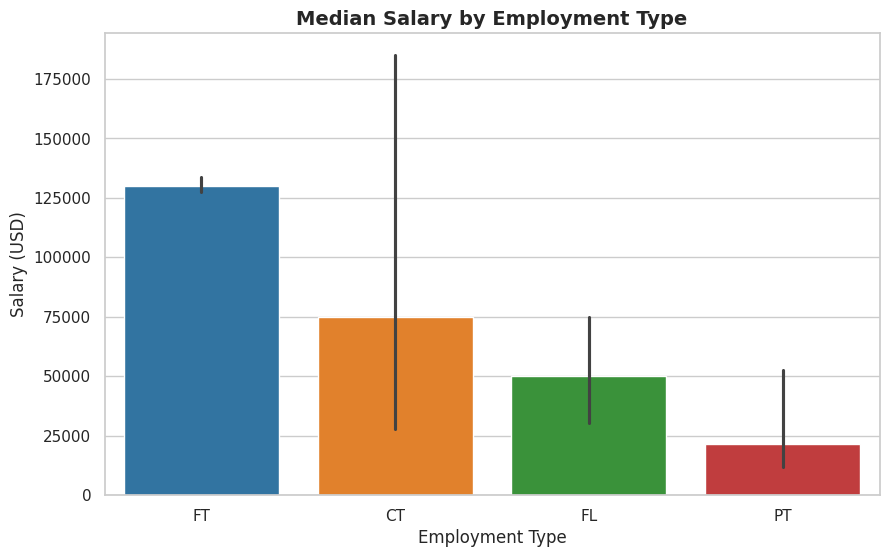

In [78]:
emp_order = jobs.groupby('employment_type')['salary_in_usd'].median().sort_values(ascending=False).index

sns.barplot(
    x='employment_type',
    y='salary_in_usd',
    data=jobs,
    estimator=np.median,
    order=emp_order,
    palette='tab10'
)

plt.title('Median Salary by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Salary (USD)')
plt.show()

Full-time employment dominates the dataset and offers the highest and most consistent median salary at $130,000. The other employment type, such as Contract, Freelance, and Part-Time, they have too few entries to draw strong conclusions, though their wide error bars suggest high variability in pay that likely depends on individual arrangements rather than market standards

# ________________________________________________________________________________________________________________

# **Key Insights**

### 1. **Experience level is the strongest salary driver.** Median salary grows consistently from ~62K USD (Entry-level) to ~190K USD (Executive), nearly tripling across career stages. However, job role and location can sometimes override experience — as seen in mid-level roles earning above 400K USD.

### 2. **Medium-sized companies pay the most.** Despite large companies being associated with bigger budgets, medium-sized companiesoffer the highest median salary at ~137K USD, suggesting a competitive edge in attracting talent.

### 3. **On-site roles pay slightly more than remote.** On-site positions lead at 137,500 USD, followed closely by remote at 130,000 USD. Thedifference is small, suggesting work arrangement alone is not a strong salarydeterminant.

### 4. **The US is the most reliable market.** While Israel and Puerto Rico show higher median salaries, their small sample sizesmake these figures less dependable. The US offers the best balance of competitivepay and job volume.

### 5. **Data science salaries nearly doubled from 2020 to 2023.** The sharpest growth occurred between 2021 and 2022, likely driven by thepost-pandemic tech boom and increased demand for data-driven decision-making.

### 6. **Full-time employment dominates and pays the most.** Over 98% of roles in the dataset are full-time, with a median salary of 130,000 USD. Other employment types are too underrepresented for reliable comparison.

### 7. **Data Science Manager is the highest-paying common role.** Among the 10 most frequent job titles, Data Science Manager leads at ~175K USD, while Data Analyst serves as the entry-level benchmark at ~103K USD.

# ________________________________________________________________________________________________________________

# **Conclusion**

### This analysis of global data science salaries reveals that compensation in the field is shaped by multiple factors working together. Experience level provides the clearest salary progression, but role specialization, company size, and geographic location also play significant roles. The rapid salary growth between 2020 and 2023 underscores the increasing value placed on data science talent worldwide. For those entering or advancing in the field, targeting senior or managerial roles at medium-sized companies, particularly in the US, where it appears to offer the strongest compensation outcomes based on this dataset.

In [81]:
# Export cleaned dataset
from google.colab import files
jobs.to_csv('cleaned_ds_salaries.csv', index=False)
files.download('cleaned_ds_salaries.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>